Hyperparameter
- ITERS = 10000
- layers = [1,128,128,128,128,8]
- BATCH = 16
- NUM_HIDDEN = 1
- MOMENTUM = 0.8
- learning_rate = 1e-6
- lr_rate = [1e-3, 1e-4, 1e-6]
- lr_boundaries = [5000, 8000]

In [1]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal as normal

tf.keras.backend.set_floatx('float64')
tf.compat.v1.enable_eager_execution()

In [2]:
NUM_OF_INTERNAL = 60
TOTAL_T = 60
NUM_HIDDEN = 1
MOMENTUM = 0.8
BATCH = 16
K = 5
ITERS = 10000
SEED = 12345
TEXT = "c1_x2" #change this one

c1 = 100 * 2
c2 = 20
c3 = 50
c4 = 200
c5 = 1000
c6 = 300*1/2

In [3]:
birth =  0.000053
death =  0.000033 

alpha = 0.00135
sigma = 0.06352
beta1 = 0.2812 
beta2 = 0.15838 
beta3 = 0.0388 
delta1 = 0.28505
delta2 = 0.28269
delta3 = 0.14206
gamma = 0.30954
p1 = 0.01845
p2 = 0.1431
mu = 0.0042
sigma1 = 0.09275
sigma2 = 0.03887
sigma3 = 0.07517
sigma4 = 0.06302
sigma5 = 0.07878
sigma6 = 0.06123
sigma7 = 0.0611
sigma8 = 0.06199

N = 6629870
S0 = 3674149/N
V0 = 2845438/N
E0 = 67789/N
I10 = 12113/N
I20 = 498/N
I30 = 96/N
R0 = 28911/N
D0 = 876/N

init = [S0, V0, E0, I10, I20, I30, R0, D0]

In [4]:
k0 = 0.006
k1 = -0.1341

def p1fn(alpha):
    return k0 + k1 * alpha

In [5]:
class Solver(object):

    def __init__(self, seed_var):
        self.valid_size = BATCH
        self.batch_size = BATCH
        
        self.num_iterations = ITERS
        self.print_frequency = 100
        self.lr_values = [1e-3, 1e-4, 1e-6]
        self.lr_boundaries = [5000, 8000]
        self.config = Config()

        self.model = WholeNet(seed_var)
        lr_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(self.lr_boundaries, self.lr_values)
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, epsilon=1e-7)

    def train(self):
        """Training the model"""
        start_time = time.time()
        training_history = []
        control_output = [] 
        
        dW = self.config.sample(self.valid_size)
        valid_data = dW
        for step in range(self.num_iterations+1):
            if step % self.print_frequency == 0:
                cost, row_out0 = self.model(valid_data, training=True)
                elapsed_time = time.time() - start_time
                training_history.append([step, cost, elapsed_time])
                print("step: %5u, Cost: %.4e, elapsed time: %3u" % (step, cost, elapsed_time))
            if step == self.num_iterations:
                cost1, row_out1 = self.model(valid_data, training=True)
                row_output = row_out1.numpy()
                control_output.append(row_output)
            self.train_step(self.config.sample(self.batch_size))
        self.training_history = training_history
        self.control_output = control_output

    @tf.function
    def train_step(self, train_data):
        """Updating the gradients"""
        with tf.GradientTape(persistent=True) as tape:
            loss = self.model(train_data, training = True)
        grad = tape.gradient(loss, self.model.trainable_variables)
        del tape
        self.optimizer.apply_gradients(zip(grad, self.model.trainable_variables))

In [6]:
class WholeNet(tf.keras.Model):
    """Building the neural network architecture"""
    def __init__(self,seed_var):
        super(WholeNet, self).__init__()
        self.config = Config()
        self.subnet = [FNNet(seed_var) for _ in range(self.config.num_time_interval)]

    def call(self, dw, training):
        x_init = tf.ones([1, self.config.dim_x], dtype=tf.dtypes.float64) * init
        time_stamp = np.arange(0, self.config.num_time_interval) * self.config.delta_t
        all_ones = tf.ones([tf.shape(dw)[0], 1], dtype=tf.dtypes.float64)

        # initial state
        x = tf.matmul(all_ones, x_init)

        # initial cost functional
        l = 0.0 
        u_set = []
        for t in range(0, self.config.num_time_interval):
            u = self.subnet[t](x, training)
            u_set.append(tf.stack([u], axis=0))   
            l = l + self.config.f_fn(time_stamp[t], x, u) * self.config.delta_t
            x = x + self.config.b_fn(time_stamp[t], x, u) * self.config.delta_t + self.config.sigma_fn(time_stamp[t], x, u) * dw[:,:,  t]

        # control variable
        control_u = tf.stack(u_set, axis=0)
        row_ave2 = tf.reduce_mean(control_u, axis=2)
        row_out1 = tf.squeeze(row_ave2, axis=[1,2])
        #print("u timepath2", row_ave2)
        
        # terminal condition
        l = l + self.config.h_fn(self.config.total_time, x)
        cost = tf.reduce_mean(l) 
        return cost, row_out1


In [7]:
class FNNet(tf.keras.Model):
    def __init__(self, seed_var):
        super(FNNet, self).__init__()
        self.config = Config()

        tf.random.set_seed(seed_var)
        np.random.seed(seed_var)
        
        num_hiddens = [self.config.dim_x + NUM_HIDDEN, self.config.dim_x + NUM_HIDDEN, self.config.dim_x + NUM_HIDDEN]
        self.bn_layers = [
            tf.keras.layers.BatchNormalization(
                momentum=MOMENTUM,
                epsilon=1e-6,
                beta_initializer=tf.random_normal_initializer(0.0, stddev=0.1,seed=seed_var),
                gamma_initializer=tf.random_uniform_initializer(0.1, 0.5,seed=seed_var)
            )
            for _ in range(len(num_hiddens) + 2)]
        self.dense_layers = [tf.keras.layers.Dense(num_hiddens[i],
                                                   use_bias=True,
                                                   activation='tanh')
                             for i in range(len(num_hiddens))]
        
        # final output should be gradient of size dim_u
        self.dense_layers.append(tf.keras.layers.Dense(self.config.dim_u, activation='sigmoid'))

    def call(self, x, training):
        x = self.bn_layers[0](x, training)
        for i in range(len(self.dense_layers) - 1):
            x = self.dense_layers[i](x)
            x = self.bn_layers[i+1](x, training)
            x = tf.nn.tanh(x)
        x = self.dense_layers[-1](x)
        x = self.bn_layers[-1](x, training)
        return tf.nn.tanh(x) * 0.012 + 0.016

In [8]:
class Config(object):
    """function config"""
    def __init__(self):
        super(Config, self).__init__()
        self.dim_x = 8
        self.dim_u = 1
        self.num_time_interval = NUM_OF_INTERNAL
        self.total_time = TOTAL_T
        self.delta_t = (self.total_time + 0.0) / self.num_time_interval
        self.sqrth = np.sqrt(self.delta_t)
        self.t_stamp = np.arange(0, self.num_time_interval) * self.delta_t

    # sample function
    def sample(self, num_sample):
        dw_sample = normal.rvs(size=[num_sample, self.dim_x, self.num_time_interval]) * self.sqrth
        return dw_sample

    # cost functional integral item
    def f_fn(self, t, x, u):
        tensors = []
        for i in range(BATCH):
            S = x[i][0]
            V = x[i][1]
            E = x[i][2]
            I1 = x[i][3]
            I2 = x[i][4]
            I3 = x[i][5]
            R = x[i][6]
            D = x[i][7]
            alpha = u[i][0]  
            cost = (c1 * alpha ** 2 + c2 * E + (c3*I1 + c4*I2 + c5*I3) + c6 * (tf.maximum(tf.cast(0, tf.float64), 1-(S+V+R)))) 
            combined_cost = tf.stack([cost], axis=0)
            tensors.append(combined_cost)
            combined_tensor = tf.stack(tensors, axis=0)
        return tf.reduce_sum(combined_tensor, 1, keepdims=True)

    # cost fuctional terminal function
    def h_fn(self, t, x):
        return 0

    def b_fn(self, t, x, u):
        tensors = []
        for i in range(BATCH):
            S = x[i][0]
            V = x[i][1]
            E = x[i][2]
            I1 = x[i][3]
            I2 = x[i][4]
            I3 = x[i][5]
            R = x[i][6]
            D = x[i][7]
            alpha = u[i][0]
            dS = birth + (- ( beta1 * I1 + beta2 * I2 + beta3 * I3) * S  - alpha * S) - death*S
            dV = (alpha * S - sigma * (beta1 * I1 + beta2 * I2 + beta3 * I3) * V) - death*V
            dE = ((beta1 * I1 + beta2 * I2 + beta3 * I3) * S  + sigma * (beta1 * I1 + beta2 * I2 + beta3 * I3) * V - gamma * E) - death*E
            dI1 = (gamma * E - (delta1 + p1fn(alpha)) * I1) - death*I1
            dI2 = (p1fn(alpha) * I1 - (delta2 + p2) * I2) - death*I2
            dI3 = (p2 * I2 - (delta3 + mu) * I3) - death*I3
            dR = (delta1 * I1+ delta2 * I2 + delta3 * I3) - death*R
            dD = (mu * I3) 
            combined_ten = tf.stack([dS, dV,dE,dI1,dI2,dI3,dR,dD], axis=0)
            tensors.append(combined_ten)
            combined_tensor = tf.stack(tensors, axis=0)
        return combined_tensor

    def sigma_fn(self, t, x, u):
        #return x
        tensors = []
        for i in range(BATCH):
            S = x[i][0]
            V = x[i][1]
            E = x[i][2]
            I1 = x[i][3]
            I2 = x[i][4]
            I3 = x[i][5]
            R = x[i][6]
            D = x[i][7]
            sig_S = sigma1*S
            sig_V = sigma2*V
            sig_E = sigma3*E
            sig_I1 = sigma4*I1
            sig_I2 = sigma5*I2
            sig_I3 = sigma6*I3
            sig_R = sigma7*R
            sig_D = sigma8*D
            combined_sig = tf.stack([sig_S, sig_V,sig_E,sig_I1,sig_I2,sig_I3,sig_R,sig_D], axis=0)
            tensors.append(combined_sig)
            combined_tensor = tf.stack(tensors, axis=0)
        return combined_tensor

In [9]:
output_table = np.zeros((int(round(ITERS) / 100) + 1, 2 + int(round(K))))
control_outs_table = np.zeros((int(round(K)), TOTAL_T))


def main():
    solver = Solver(seed_var=SEED)
    print('Training time %3u:' % (1))
    solver.train()
    data = np.array(solver.training_history)
    control_output_data = np.array(solver.control_output)
    k = K
    
    output = np.zeros((len(data[:, 0]), 2 + k))
    output[:, 0] = data[:, 0]
    output[:, 1] = data[:, 2]
    output[:, 2] = data[:, 1]
    output_table[:, 0] = data[:, 0]
    output_table[:, 1] = data[:, 2]
    output_table[:, 2] = data[:, 1]

    
    control_outs = np.zeros((k, len(control_output_data[0])))
    control_outs[0] = control_output_data[0]

    
    for i in range(k - 1):
        print('Training time %3u:' % (i + 2))
        solver = Solver(seed_var=12345+1+i)  
        solver.train()
        data = np.array(solver.training_history)
        control_output_data = np.array(solver.control_output)
        output[:, 3 + i] = data[:, 1]
        output_table[:, 3 + i] = data[:, 1]
        control_outs[1+i] = control_output_data[0]
        control_outs_table[1+i] = control_output_data[0]

    a = ['%d', '%.5e']
    for _ in range(k):
        a.append('%.5e')
    
    con_format = ['%.5e']
    for _ in range(len(control_output_data[0])-1):
        con_format.append('%.5e')
        
    np.savetxt('./Sto_control_Opt_Vacc_'+str(TEXT)+'.csv', control_outs, fmt=con_format, delimiter=',')
    np.savetxt('./Sto_control_Loss_'+str(TEXT)+'.csv', output, fmt=a, delimiter=',')
    print('Solving is done!')

if __name__ == '__main__':
    main()


2024-10-01 15:57:49.674265: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2024-10-01 15:57:49.674590: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Training time   1:
step:     0, Cost: 7.8223e+02, elapsed time:   4


2024-10-01 16:03:42.127564: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)


step:   100, Cost: 7.7734e+02, elapsed time: 565
step:   200, Cost: 7.7581e+02, elapsed time: 583
step:   300, Cost: 7.7399e+02, elapsed time: 602
step:   400, Cost: 7.7090e+02, elapsed time: 622
step:   500, Cost: 7.6874e+02, elapsed time: 642
step:   600, Cost: 7.6771e+02, elapsed time: 661
step:   700, Cost: 7.6773e+02, elapsed time: 681
step:   800, Cost: 7.6728e+02, elapsed time: 700
step:   900, Cost: 7.6757e+02, elapsed time: 720
step:  1000, Cost: 7.6706e+02, elapsed time: 740
step:  1100, Cost: 7.6734e+02, elapsed time: 759
step:  1200, Cost: 7.6531e+02, elapsed time: 779
step:  1300, Cost: 7.6518e+02, elapsed time: 799
step:  1400, Cost: 7.6656e+02, elapsed time: 820
step:  1500, Cost: 7.6573e+02, elapsed time: 840
step:  1600, Cost: 7.6747e+02, elapsed time: 861
step:  1700, Cost: 7.6622e+02, elapsed time: 881
step:  1800, Cost: 7.6743e+02, elapsed time: 901
step:  1900, Cost: 7.6698e+02, elapsed time: 921
step:  2000, Cost: 7.6814e+02, elapsed time: 941
step:  2100, Cost: 7

In [10]:
loss_val = output_table[:, 2]
for i in range(K-1):
    loss_val = loss_val + output_table[:, i+3]
average_cost = loss_val/K
print(average_cost)

[681.66838543 677.61748157 674.99307066 670.36256371 666.71294102
 664.86535496 663.08282072 661.90546179 660.99213319 660.16319995
 658.14563844 657.43346315 656.12309436 656.14345342 654.73930636
 654.27409421 654.12482351 653.85572126 652.88296784 652.42875925
 652.78047167 652.14238761 651.98905129 652.11576067 651.8721897
 652.2381254  651.03169836 650.99907662 650.99076597 651.06566298
 651.01185232 650.51535086 650.70078837 650.90481461 650.99167483
 650.09320292 650.34368801 650.46909252 650.46913697 650.02701947
 649.99132625 649.98772719 650.04107705 649.8500292  650.42141742
 650.38707193 649.75659738 649.66842017 649.95645953 650.06848472
 649.96859114 649.94111022 649.91044392 649.90474064 649.90231101
 649.88863308 649.87861635 649.86019633 649.89659962 649.89267125
 649.87464709 649.85747414 649.81390066 649.76956427 649.76429919
 649.75702058 649.74413782 649.72265488 649.71371579 649.72333684
 649.69511201 649.71400078 649.68548896 649.68134287 649.65211917
 649.639730

In [11]:
print(output_table)
#cost1 = output_table[:, 2]
#cost2 = output_table[:, 3]
#cost3 = output_table[:, 4]

# Compute averages
#average_cost = (cost1 + cost2+ cost3) / 3
#print(average_cost)

[[0.00000000e+00 4.98980498e+00 7.82227694e+02 5.98011406e+02
  5.87222351e+02 6.40881982e+02 7.99998495e+02]
 [1.00000000e+02 5.65571776e+02 7.77341554e+02 5.93150968e+02
  5.79080598e+02 6.44443719e+02 7.94070569e+02]
 [2.00000000e+02 5.83980521e+02 7.75812788e+02 5.89317436e+02
  5.74288050e+02 6.44038909e+02 7.91508170e+02]
 [3.00000000e+02 6.02983694e+02 7.73986878e+02 5.84629873e+02
  5.66665371e+02 6.37704730e+02 7.88825967e+02]
 [4.00000000e+02 6.22502553e+02 7.70896585e+02 5.80057033e+02
  5.64477754e+02 6.33148416e+02 7.84984918e+02]
 [5.00000000e+02 6.42093977e+02 7.68735269e+02 5.76272631e+02
  5.66629283e+02 6.30840434e+02 7.81849158e+02]
 [6.00000000e+02 6.61655114e+02 7.67706070e+02 5.74050458e+02
  5.62939882e+02 6.32846335e+02 7.77871359e+02]
 [7.00000000e+02 6.81295646e+02 7.67727966e+02 5.71718022e+02
  5.64289422e+02 6.30541652e+02 7.75250248e+02]
 [8.00000000e+02 7.00953138e+02 7.67277500e+02 5.69507074e+02
  5.65922589e+02 6.29163645e+02 7.73089857e+02]
 [9.000000

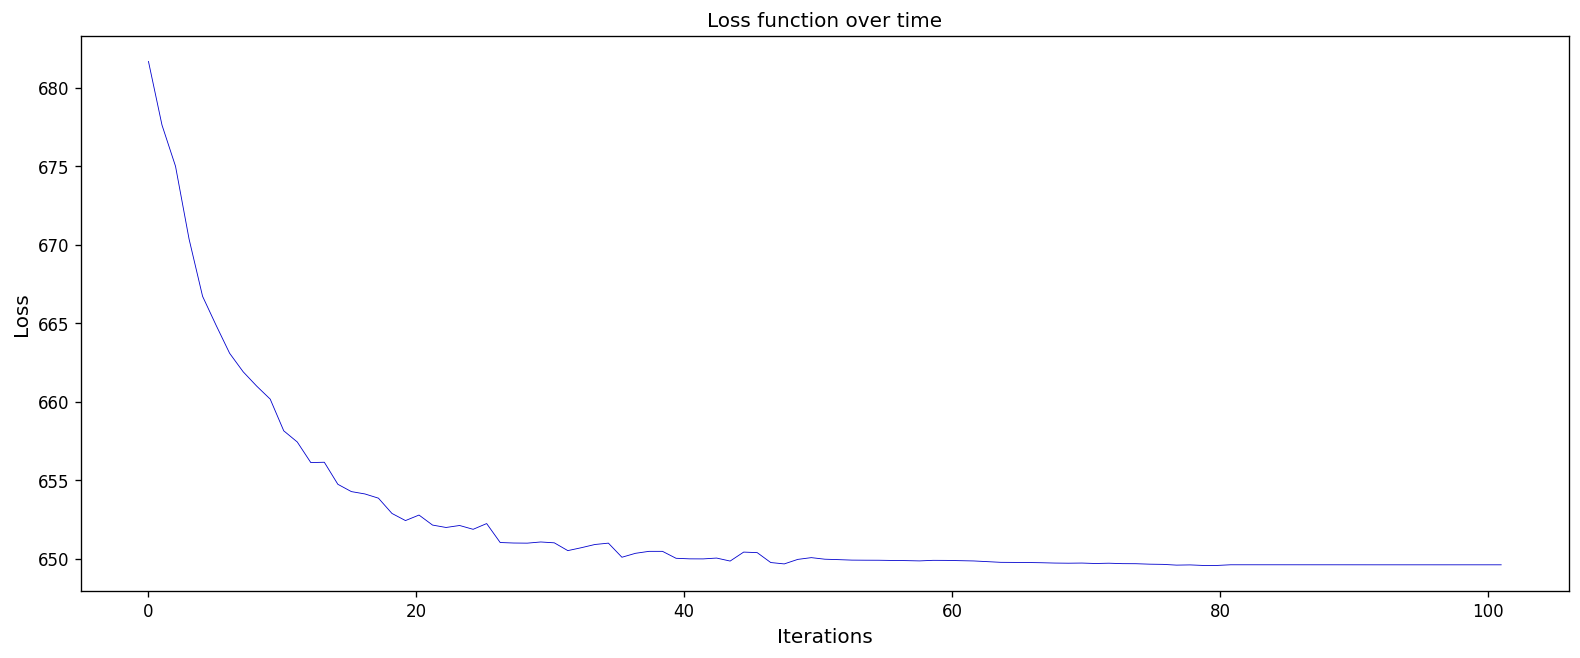

In [12]:
t = np.linspace(0, len(average_cost), len(average_cost))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)
ax0.plot(t, average_cost, lw = 0.5, color = 'mediumblue', label = 'average_cost')
ax0.set_xlabel('Iterations', fontsize = 12)
ax0.set_ylabel('Loss', fontsize = 12)
ax0.set_title('Loss function over time', fontsize = 12)
plt.savefig('Loss_'+str(TEXT)+'.png')

[0.02779098 0.02779182 0.02777667 0.02776192 0.02774025 0.02771151
 0.02768216 0.02764335 0.0275993  0.02756583 0.02756119 0.02742965
 0.02726902 0.02713989 0.02682839 0.02661122 0.02643124 0.02567948
 0.02550747 0.02504088 0.02493361 0.02463425 0.02413752 0.02354487
 0.02307377 0.02230765 0.0214677  0.02087078 0.01976159 0.01964331
 0.01853571 0.01767608 0.0167509  0.01629939 0.01550689 0.01489384
 0.01345053 0.01215465 0.01196879 0.01154922 0.01079925 0.01012525
 0.00957421 0.00882391 0.00833189 0.00781636 0.00695784 0.00662486
 0.00583327 0.00521683 0.00495422 0.00472843 0.00452054 0.00441576
 0.00434505 0.00430785 0.00429137 0.00428526 0.00428424 0.0042817 ]


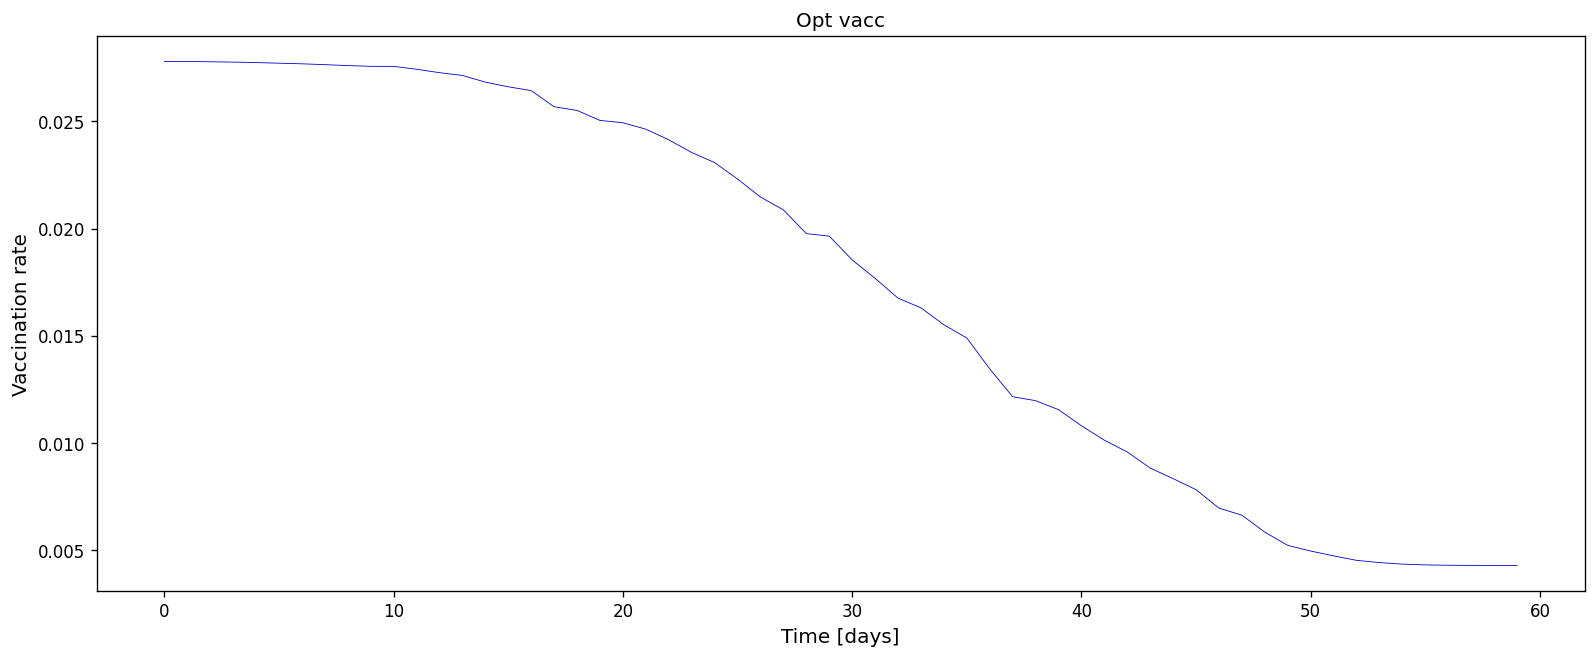

In [13]:
print(control_outs_table[1:2,:].flatten())
t = np.linspace(0, len(control_outs_table[1:2,:].flatten()),len(control_outs_table[1:2,:].flatten()))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)
ax0.plot(control_outs_table[1:2,:].flatten(), lw = 0.5, color = 'mediumblue', label = 'average_cost')
ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Vaccination rate', fontsize = 12)
ax0.set_title('Opt vacc', fontsize = 12)
plt.savefig('Opt vacc_'+str(TEXT)+'.png')